Saving svm_farming_datasets.xlsx to svm_farming_datasets.xlsx
Dataset Loaded Successfully!

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy
==== Results for C = 0.01 =====
Accuracy: 1.0
Confusion Matrix:
 [[ 9  0]
 [ 0 12]]
Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

==== Results for 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


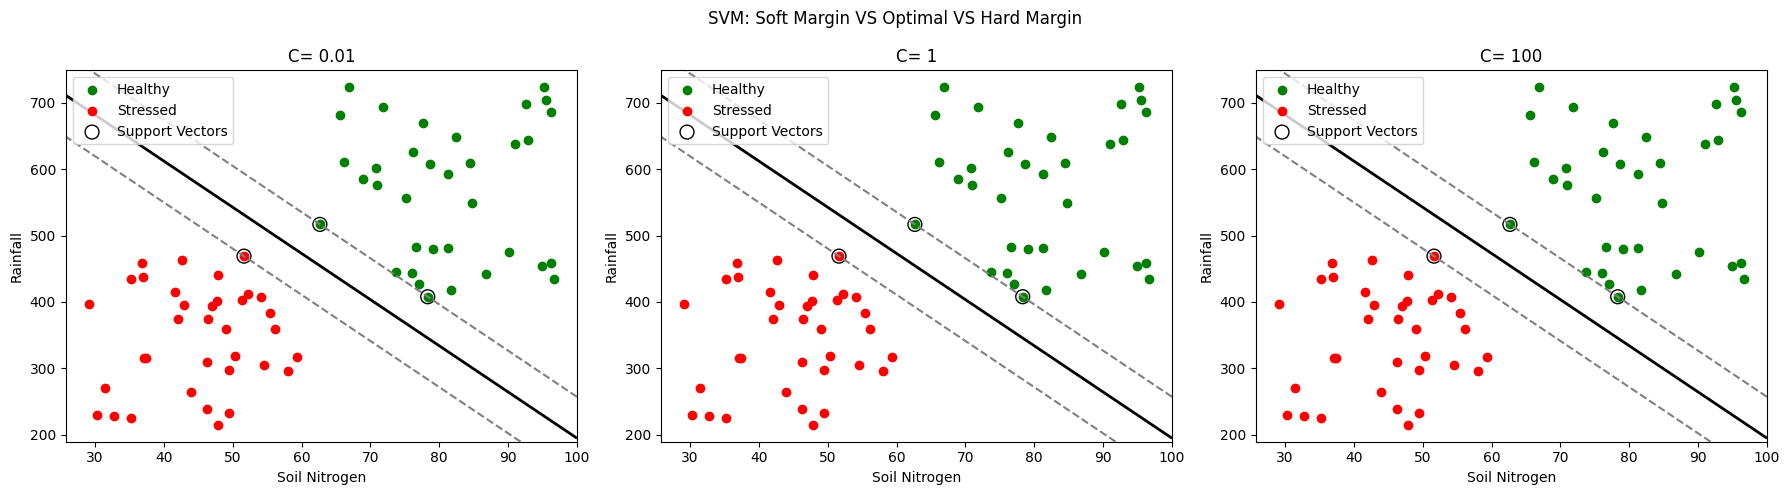

In [ ]:

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

df= pd.read_excel(file_name)
print("Dataset Loaded Successfully!\n")
print(df.head())

df.columns = df.columns.str.strip()

df.rename(columns={
    "Soil Nitrogen (mg/kg)": "Soil_Nitrogen",
    "Avg Rainfall (mm)": "Rainfall"
}, inplace=True)

if "Sample ID" in df.columns:
    df.drop(columns=["Sample ID"], inplace=True)

if 'Class Label' in df.columns and 'Class' in df.columns:
    df.drop(columns=['Class'], inplace=True)

if 'Class Label' in df.columns:
    df.rename(columns={"Class Label": "Class"}, inplace=True)

X= df[["Soil_Nitrogen", "Rainfall"]]
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


def train_and_plot(C, subplot_index):
    model = svm.SVC(kernel="linear", C=C)
    model.fit(X_train, y_train)
    # Predictions
    y_pred = model.predict(X_test)
    # Evaluation
    print(f"==== Results for C = {C} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    plt.subplot(1, 3, subplot_index)

    for label, color in zip([1, -1], ['green', 'red']):
        subset = df[df["Class"] == label]
        plt.scatter(subset["Soil_Nitrogen"],
                    subset["Rainfall"],
                    c=color,
                    label=("Healthy" if label == 1 else "Stressed"))

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z= model.decision_function(xy).reshape(XX.shape)
    # Boundary
    ax.contour(XX, YY, Z, levels=[0], linewidths=2, colors='black')
    # Margins
    ax.contour(XX, YY, Z, levels=[-1, 1], linestyles=["--", "--"], colors='gray')
    # Support vectors
    ax.scatter(model.support_vectors_[:, 0],
               model.support_vectors_[:, 1],
               s=100, facecolors='none',
               edgecolors='black',
               label='Support Vectors')
    plt.xlabel("Soil Nitrogen")
    plt.ylabel("Rainfall")
    plt.title(f"C= {C}")
    plt.legend()
#
#8. Compare Different C Values
#
plt.figure(figsize=(18, 5))
C_values = [0.01, 1, 100]
for i, C in enumerate(C_values):
    train_and_plot(C, i+1)
plt.suptitle("SVM: Soft Margin VS Optimal VS Hard Margin")
plt.tight_layout()
plt.show()